# **About:**
- The aim of this project is to train a model that can breakdown an abstract from a medical paper and segment it into sections like objective, methods, conclusion, etc.

- This is based on the data from the following paper: [Paper](https://arxiv.org/abs/1710.06071)

# **Helper Functions:**

In [1]:
# Function for getting labeled data from text file.
import pandas as pd
import re

def get_labeled_data(file_path):
  # Step 1: Read the entire text content from the file
  with open(file_path, "r", encoding="utf-8") as f:
      raw_text = f.read()

  # Step 2: Split into individual articles using the PubMed ID marker
  articles = re.split(r"^###", raw_text, flags=re.MULTILINE)

  # Step 3: Process each article block
  records = []
  for article in articles:
      if not article.strip():
          continue
      lines = article.strip().splitlines()
      pmid = lines[0].strip()
      for line in lines[1:]:
          if "\t" in line:
              section, text = line.split("\t", 1)
              records.append({
                  "PMID": pmid,
                  "SECTION": section.strip(),
                  "TEXT": text.strip()
              })

  # Step 4: Convert to a DataFrame
  df = pd.DataFrame(records)

  return df

In [2]:
# Function to calculate various metrics for the given binary prediction.
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def metrics_calculation(Y_true, Y_pred, average="binary"):
  accuracy = accuracy_score(Y_true, Y_pred)
  precision, recall, f1_score, _ = precision_recall_fscore_support(Y_true, Y_pred, beta=1, average=average)
  model_results = {
      "accuracy": accuracy,
      "precision": precision,
      "recall": recall,
      "f1_score": f1_score
  }

  return model_results

In [3]:
# Function for plotting loss and accuracy curves based on training history.

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

def plot_loss_curves(model_history):
  loss = model_history.history['loss']
  accuracy = model_history.history['accuracy']

  val_loss = model_history.history['val_loss']
  val_accuracy = model_history.history['val_accuracy']

  epochs = range(1,len(model_history.history['loss'])+1)

  fig, ax = plt.subplots(1,2, figsize=(14,7))

  sns.lineplot(x=epochs, y=loss, label="Training Loss", color='blueviolet', ax=ax[0])
  sns.lineplot(x=epochs, y=val_loss, label="Validation Loss", color='gold', ax=ax[0])
  ax[0].set_xlabel('Epochs')
  ax[0].set_ylabel('Loss')
  ax[0].set_title("Loss Curves")
  ax[0].grid(True)

  sns.lineplot(x=epochs, y=accuracy, label="Training Accuracy", color='blueviolet', ax=ax[1])
  sns.lineplot(x=epochs, y=val_accuracy, label="Validation Accuracy", color='gold', ax=ax[1])
  ax[1].set_xlabel('Epochs')
  ax[1].set_ylabel('Accuracy')
  ax[1].set_title("Accuracy Curves")
  ax[1].grid(True)

  plt.legend()
  plt.tight_layout()
  plt.show()



# Writing a function to visualize confusion matrix.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

def visualize_confusion_matrix(actual_class, pred_class, class_list):
  cm = confusion_matrix(actual_class, pred_class)
  plt.figure(figsize=(7,7))
  sns.heatmap(cm, annot=True, fmt='g', cbar=True, cmap='PuRd', linewidth=0.7, linecolor="black",
              xticklabels=class_list, yticklabels=class_list)
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  plt.xlabel('Predicted Classes')
  plt.ylabel('Actual Classes')
  plt.title('Confusion Matrix')
  plt.show()

# **Setting up Callbacks:**

In [4]:
import datetime
import tensorflow as tf

# Creating a functionized version because we need to create a TensorBoard for every model.
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%d%m%Y-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir = log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback



# Creating a function to save weights using ModelCheckpoint.
def create_save_weights_callback(file_name):
  filepath = "model_weights/" + file_name + ".weights.h5"
  cp_callback = tf.keras.callbacks.ModelCheckpoint(
      filepath = filepath,
      save_best_only = True,
      save_weights_only = True,
      monitor = "val_accuracy",
      mode = "max",
      verbose = 1
  )
  return cp_callback





# Same functions but for when we are using models from TensorFlow Hub.
import tf_keras

def create_tensorboard_callback_hub(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%d%m%Y-%H%M%S")
  tensorboard_callback = tf_keras.callbacks.TensorBoard(
      log_dir = log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback



# Creating a function to save weights using ModelCheckpoint.
def create_save_weights_callback_hub(file_name):
  filepath = "model_weights/" + file_name + ".weights.h5"
  cp_callback = tf_keras.callbacks.ModelCheckpoint(
      filepath = filepath,
      save_best_only = True,
      save_weights_only = True,
      monitor = "val_accuracy",
      mode = "max",
      verbose = 1
  )
  return cp_callback

# **Dataset:**

## **Getting the Dataset:**

In [9]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct

fatal: destination path 'pubmed-rct' already exists and is not an empty directory.


## **Preparing the Dataset (20k):**

In [10]:
train = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt")
val = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt")
test = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt")

In [11]:
train.head()

,PMID,SECTION,TEXT
0,24293578,OBJECTIVE,To investigate the efficacy of @ weeks of dail...
1,24293578,METHODS,A total of @ patients with primary knee OA wer...
2,24293578,METHODS,Outcome measures included pain reduction and i...
3,24293578,METHODS,Pain was assessed using the visual analog pain...
4,24293578,METHODS,Secondary outcome measures included the Wester...


### **Adding new features:**

In [12]:
# Adding "LINE_NO" in each PMID.
train["LINE_NO"] = train.groupby("PMID").cumcount()+1
val["LINE_NO"] = val.groupby("PMID").cumcount()+1
test["LINE_NO"] = test.groupby("PMID").cumcount()+1

# Adding "TOTAL_LINES" in each PMID.
train["TOTAL_LINES"] = train.groupby("PMID")["LINE_NO"].transform("max")
val["TOTAL_LINES"] = val.groupby("PMID")["LINE_NO"].transform("max")
test["TOTAL_LINES"] = test.groupby("PMID")["LINE_NO"].transform("max")

# Adding "NUM_TOKENS".
train["NUM_TOKENS"] = train["TEXT"].apply(lambda x: len(x.split()))
val["NUM_TOKENS"] = val["TEXT"].apply(lambda x: len(x.split()))
test["NUM_TOKENS"] = test["TEXT"].apply(lambda x: len(x.split()))

train

,PMID,SECTION,TEXT,LINE_NO,TOTAL_LINES,NUM_TOKENS
0,24293578,OBJECTIVE,To investigate the efficacy of @ weeks of dail...,1,12,49
1,24293578,METHODS,A total of @ patients with primary knee OA wer...,2,12,27
2,24293578,METHODS,Outcome measures included pain reduction and i...,3,12,15
3,24293578,METHODS,Pain was assessed using the visual analog pain...,4,12,14
4,24293578,METHODS,Secondary outcome measures included the Wester...,5,12,35
...,...,...,...,...,...,...
180035,26227186,RESULTS,For the absolute change in percent atheroma vo...,8,12,95
180036,26227186,RESULTS,"For PAV , a significantly greater percentage o...",9,12,28
180037,26227186,RESULTS,Both strategies had acceptable side effect pro...,10,12,18
180038,26227186,CONCLUSIONS,"Compared with standard statin monotherapy , th...",11,12,30


### **Exploratory Data Analysis (20k):**

Text(0.5, 1.0, 'Count of each section')

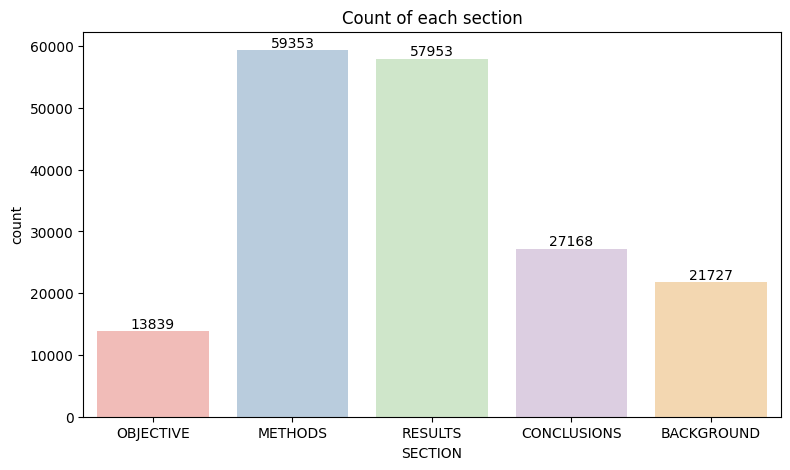

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize = (9,5))
ax = plt.subplot(1,1,1)
sns.countplot(data=train, x="SECTION", hue="SECTION", palette="Pastel1", ax=ax)
for container in ax.containers:
  ax.bar_label(container)
plt.title("Count of each section")

Text(0.5, 1.0, 'Distribution of total number of lines')

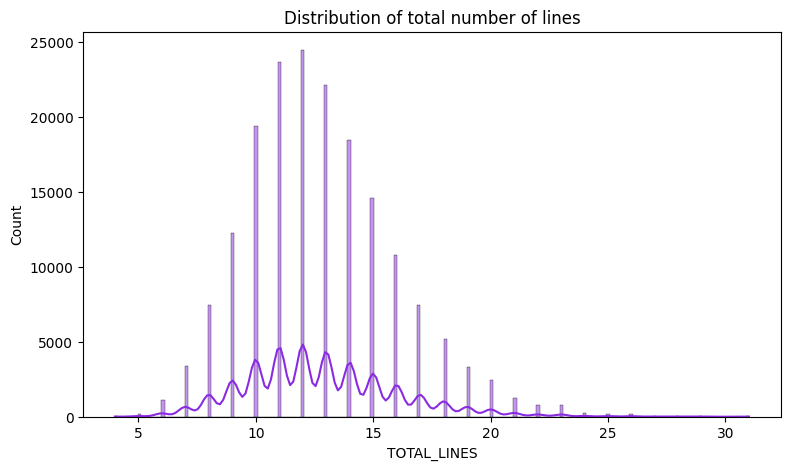

In [14]:
# Distribution of total number of lines.
plt.figure(figsize = (9,5))
sns.histplot(data=train, x="TOTAL_LINES", color="blueviolet", kde=True)
plt.title("Distribution of total number of lines")

25th percentile: 16.0
50th percentile: 23.0
75th percentile: 33.0
80th percentile: 36.0
90th percentile: 45.0
95th percentile: 55.0


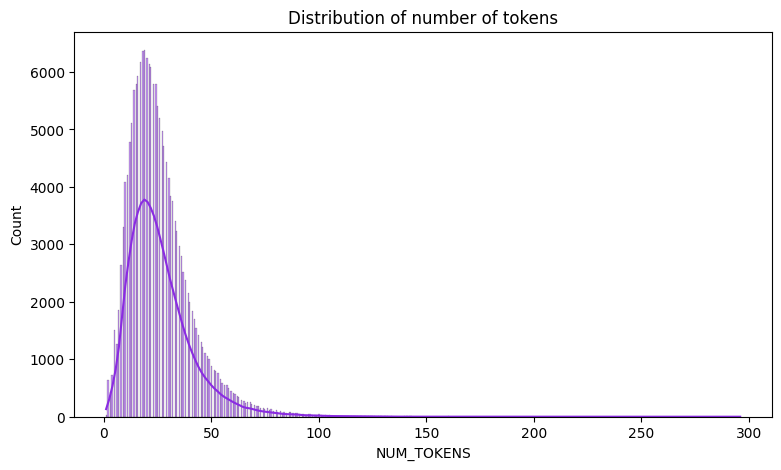

In [15]:
# Distribution of number of tokens.
import numpy as np

plt.figure(figsize = (9,5))
sns.histplot(data=train, x="NUM_TOKENS", color="blueviolet", kde=True)
plt.title("Distribution of number of tokens")

print(f"25th percentile: {np.percentile(train['NUM_TOKENS'], 25)}")
print(f"50th percentile: {np.percentile(train['NUM_TOKENS'], 50)}")
print(f"75th percentile: {np.percentile(train['NUM_TOKENS'], 75)}")
print(f"80th percentile: {np.percentile(train['NUM_TOKENS'], 80)}")
print(f"90th percentile: {np.percentile(train['NUM_TOKENS'], 90)}")
print(f"95th percentile: {np.percentile(train['NUM_TOKENS'], 95)}")

### **Encoding target variables:**

In [16]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
train["SECTION"] = target_encoder.fit_transform(train["SECTION"])
val["SECTION"] = target_encoder.transform(val["SECTION"])
test["SECTION"] = target_encoder.transform(test["SECTION"])

# Getting class mapping.
classes = dict(zip(target_encoder.transform(target_encoder.classes_), target_encoder.classes_))
classes

{np.int64(0): 'BACKGROUND',
 np.int64(1): 'CONCLUSIONS',
 np.int64(2): 'METHODS',
 np.int64(3): 'OBJECTIVE',
 np.int64(4): 'RESULTS'}

# **Model Implementation (20K Dataset):**

## **Model 0: Baseline**
TF-IDF Encoder + Naive Bayes.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

baseline_model = Pipeline([
    ("TF-IDF", TfidfVectorizer()),
    ("NB", MultinomialNB())
])

baseline_model.fit(train["TEXT"], train["SECTION"])

# Getting metrics values on validation set.
Y_pred = baseline_model.predict(val["TEXT"])
baseline_model_results = metrics_calculation(val["SECTION"], Y_pred, average="weighted")

print(f"Baseline Model Results:\n{baseline_model_results}")

Baseline Model Results:
{'accuracy': 0.7218323844829869, 'precision': 0.7186466952323352, 'recall': 0.7218323844829869, 'f1_score': 0.6989250353450294}


## **Model 1: Conv1D**

### **Preparing Dataset and Model Training:**
In order to optimize the training pipeline, we will convert out dataset from a Pandas DataFrame to a **tf.data.Dataset** object.

In [18]:
# Importing necessary libraries.
import tensorflow as tf
import numpy as np
import random

# Setting up random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing varaibles.
VOCAB_SIZE = 68000                                            # Specified in the paper.
MAX_LENGTH = int(np.percentile(train["NUM_TOKENS"], 95))
EMBEDDING_SIZE = 128
NUM_CLASSES = len(classes)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting given dataset into tf.data.Dataset object.
# .from_tensor_slices() converts a tensor/array/list object into a tf.data.Dataset object.
ds_train = tf.data.Dataset.from_tensor_slices((train["TEXT"].astype(str).values, train["SECTION"].values))
ds_val = tf.data.Dataset.from_tensor_slices((val["TEXT"].astype(str).values, val["SECTION"].values))
ds_test = tf.data.Dataset.from_tensor_slices((test["TEXT"].astype(str).values, test["SECTION"].values))

# Optimizing pipeline.
ds_train = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Defining model layers.
# Tokenization.
text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens = VOCAB_SIZE,
    standardize = "lower_and_strip_punctuation",
    split = "whitespace",
    ngrams = None,
    output_mode = "int",
    output_sequence_length = MAX_LENGTH,
    name = "text_vectorization_layer"
)
text_vectorizer.adapt(train["TEXT"])
vocab_20k = text_vectorizer.get_vocabulary()

# Embedding.
embedding_layer = tf.keras.layers.Embedding(
    input_dim = len(vocab_20k),                  # This makes sure that if there are lesser number of words in vocabulary than VOCAB_SIZE, it does not cause any mismatch.
    output_dim = EMBEDDING_SIZE,
    embeddings_initializer = tf.keras.initializers.RandomUniform(seed=100),
    name = "word_embedding_layer"
)

# Defining model architecture using Keras Functional API.
input = tf.keras.layers.Input(shape = (1,), dtype = tf.string, name = "input_layer")
x = text_vectorizer(input)
x = embedding_layer(x)
x = tf.keras.layers.Conv1D(filters=64, kernel_size=5, activation="relu", name="Conv1D_layer")(x)
x = tf.keras.layers.GlobalAveragePooling1D(name="global_average_pooling_layer")(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax",
                          kernel_initializer=tf.keras.initializers.GlorotUniform(seed=100),name="dense_layer")(x)

# Building the model.
model_1 = tf.keras.Model(input, output, name="model_1")

# Compiling the model.
model_1.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# Fitting the model.
model_1_history = model_1.fit(
    ds_train,
    epochs = 5,
    validation_data = ds_val,
    callbacks = [create_tensorboard_callback("model_logs", "model_1"), create_save_weights_callback("model_1")]
)

Saving TensorBoard log files to: model_logs/model_1/05032026-104816
Epoch 1/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7130 - loss: 0.7541
Epoch 1: val_accuracy improved from -inf to 0.80832, saving model to model_weights/model_1.weights.h5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 66s 11ms/step - accuracy: 0.7130 - loss: 0.7541 - val_accuracy: 0.8083 - val_loss: 0.5344
Epoch 2/5
5626/5627 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8322 - loss: 0.4719
Epoch 2: val_accuracy improved from 0.80832 to 0.81186, saving model to model_weights/model_1.weights.h5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 61s 11ms/step - accuracy: 0.8322 - loss: 0.4719 - val_accuracy: 0.8119 - val_loss: 0.5261
Epoch 3/5
5626/5627 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8672 - loss: 0.3821
Epoch 3: val_accuracy did not improve from 0.81186
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 69s 12ms/step - accuracy: 0.8672 - loss: 0.3821 - val_accuracy: 0.8091 - val_loss: 0.5583
Epoch 4/5
5626/5627 ━━━━━━━━━━━━━━━━━━━━ 0s 12m

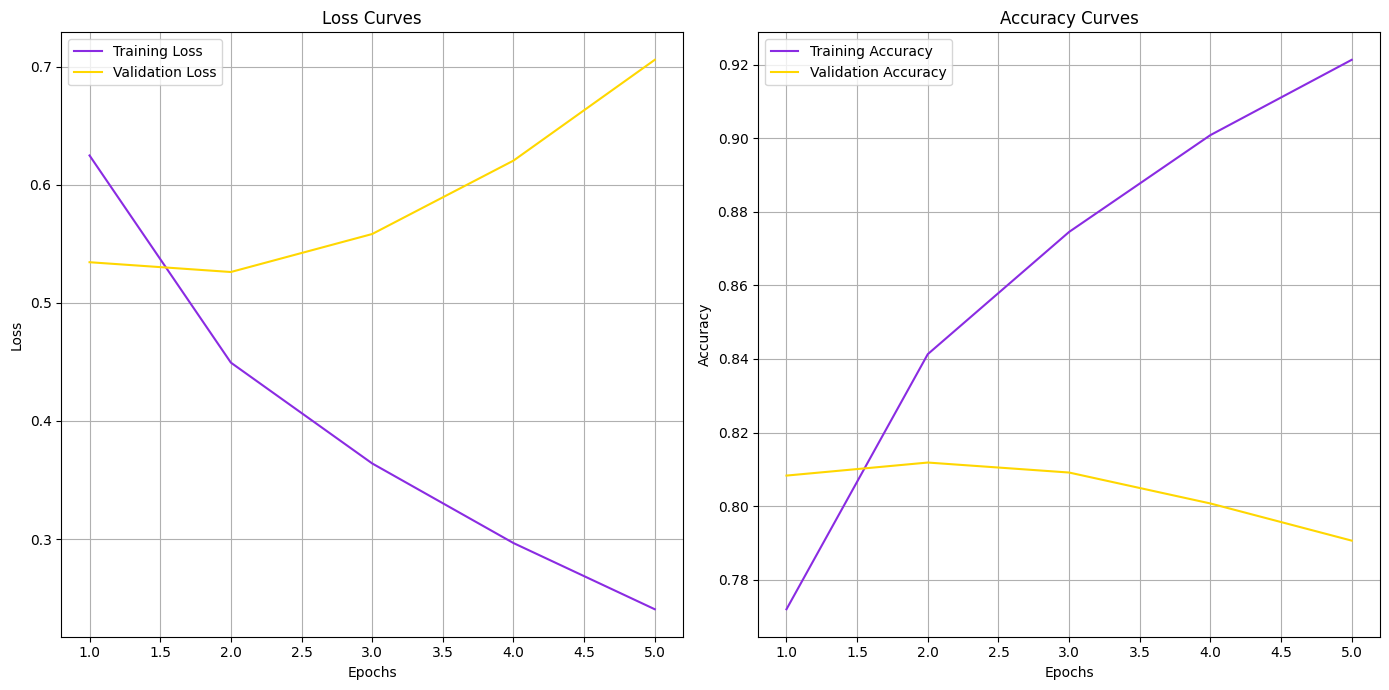

In [19]:
plot_loss_curves(model_1_history)

In [20]:
model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_layer        │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embedding_layer            │ (None, 55, 128)        │     8,299,648 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_layer (Conv1D)           │ (None, 51, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,022,993 (95.46 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,681,996 (63.64 MB)

### **Metrics Calculation:**

In [21]:
Y_pred = model_1.predict(ds_val)
Y_pred = np.argmax(Y_pred, axis=1)
model_1_results = metrics_calculation(val["SECTION"], Y_pred, average="weighted")

print(f"Model 1 Results:\n{model_1_results}")

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Model 1 Results:
{'accuracy': 0.7906461008870648, 'precision': 0.7883947338463217, 'recall': 0.7906461008870648, 'f1_score': 0.7883448845606301}


### **Conclusion:**
Conv1D model beats the baseline model by a good margin.

## **Model 2: Pretrained Word Embeddings**
We are using **Universal Sentence Encoder** as it usually performs better compared to GloVe embeddings.

### **Preparing Dataset and Model Implementation:**

In [22]:
# Importing necessary libraries.
import tensorflow as tf
import tf_keras
import tensorflow_hub as hub
import numpy as np
import random

# Setting up random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing varaibles.
VOCAB_SIZE = 68000                                            # Specified in the paper.
MAX_LENGTH = int(np.percentile(train["NUM_TOKENS"], 95))
EMBEDDING_SIZE = 128
NUM_CLASSES = len(classes)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting given dataset into tf.data.Dataset object.
ds_train = tf.data.Dataset.from_tensor_slices((train["TEXT"].astype(str).values, train["SECTION"].values))
ds_val = tf.data.Dataset.from_tensor_slices((val["TEXT"].astype(str).values, val["SECTION"].values))
ds_test = tf.data.Dataset.from_tensor_slices((test["TEXT"].astype(str).values, test["SECTION"].values))

# Optimizing pipeline.
ds_train = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Defining model layers.
use_layer = hub.KerasLayer(
    "https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2",
    input_shape = [],
    dtype = tf.string,
    trainable = False,
    name = "universal_sentence_encoder"
)

# Defining model architecture using Keras Functional API.
input = tf_keras.layers.Input(shape=(), dtype=tf.string, name="input_layer")
x = use_layer(input)
x = tf_keras.layers.Dense(128, activation="relu", name="dense_layer")(x)
output = tf_keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output_layer")(x)

# Building the model.
model_2 = tf_keras.Model(input, output, name="model_2")

# Compiling the model.
model_2.compile(
    loss = tf_keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf_keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# Fitting the model.
model_2_history = model_2.fit(
    ds_train,
    epochs = 5,
    validation_data = ds_val,
    callbacks = [create_tensorboard_callback_hub("model_logs", "model_2"), create_save_weights_callback_hub("model_2")]
)

Saving TensorBoard log files to: model_logs/model_2/05032026-110406
Epoch 1/5
5625/5627 [============================>.] - ETA: 0s - loss: 0.7313 - accuracy: 0.7203
Epoch 1: val_accuracy improved from -inf to 0.75205, saving model to model_weights/model_2.weights.h5
5627/5627 [==============================] - 86s 15ms/step - loss: 0.7314 - accuracy: 0.7203 - val_loss: 0.6558 - val_accuracy: 0.7521
Epoch 2/5
5625/5627 [============================>.] - ETA: 0s - loss: 0.6357 - accuracy: 0.7592
Epoch 2: val_accuracy improved from 0.75205 to 0.76324, saving model to model_weights/model_2.weights.h5
5627/5627 [==============================] - 85s 15ms/step - loss: 0.6357 - accuracy: 0.7591 - val_loss: 0.6215 - val_accuracy: 0.7632
Epoch 3/5
5627/5627 [==============================] - ETA: 0s - loss: 0.6012 - accuracy: 0.7728
Epoch 3: val_accuracy improved from 0.76324 to 0.76880, saving model to model_weights/model_2.weights.h5
5627/5627 [==============================] - 84s 15ms/step 

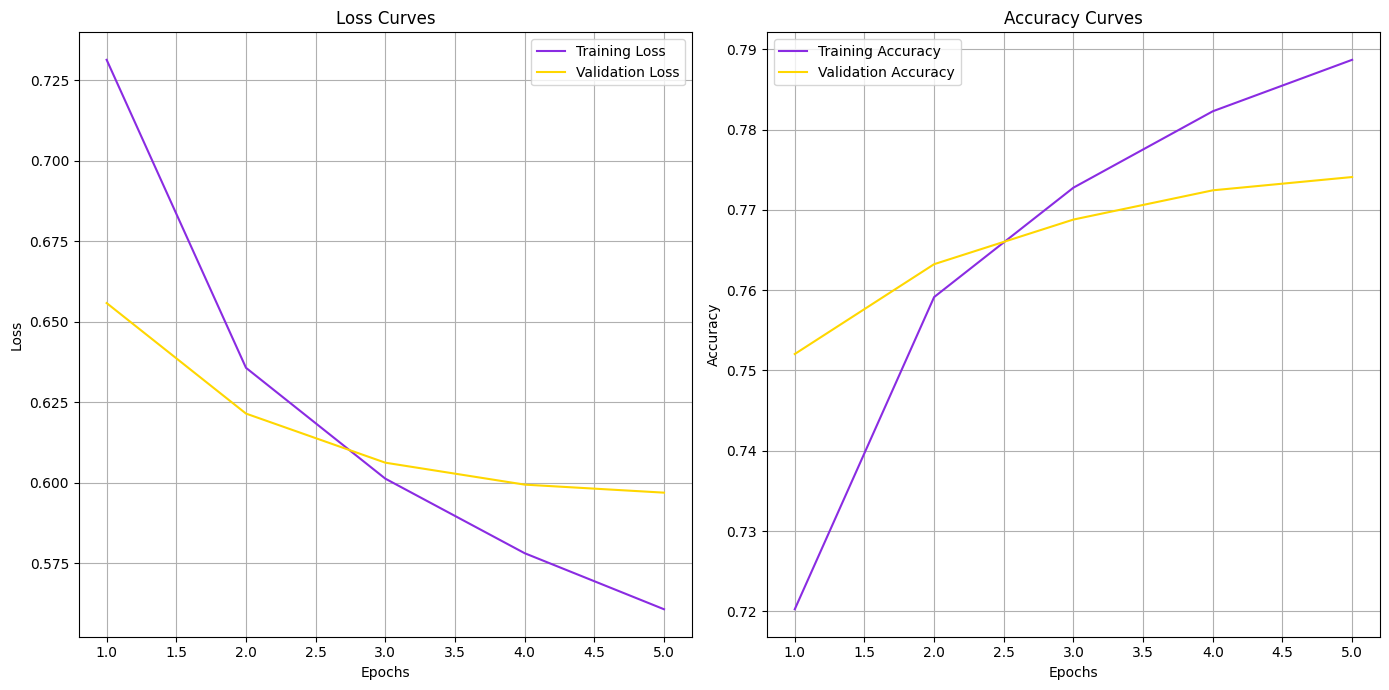

In [23]:
plot_loss_curves(model_2_history)

### **Metrics Calculation:**

In [24]:
Y_pred_soft = model_2.predict(ds_val)
Y_pred = tf.argmax(Y_pred_soft, axis=1)

model_2_results = metrics_calculation(val["SECTION"], Y_pred, average="weighted")

print(f"Model 2 Results:\n{model_2_results}")

945/945 [==============================] - 10s 11ms/step
Model 2 Results:
{'accuracy': 0.7740963855421686, 'precision': 0.7728451130899319, 'recall': 0.7740963855421686, 'f1_score': 0.7701811815248548}


### **Conclustion:**
model_2 outperforms the baseline model. However, falls short of model_1's performance.

## **Model 3: Conv1D with Character Embeddings**

### **Converting sentences into characters:**

In [26]:
train = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt")
val = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt")
test = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt")

# Adding "LINE_NO" in each PMID.
train["LINE_NO"] = train.groupby("PMID").cumcount()+1
val["LINE_NO"] = val.groupby("PMID").cumcount()+1
test["LINE_NO"] = test.groupby("PMID").cumcount()+1


# Adding "TOTAL_LINES" in each PMID.
train["TOTAL_LINES"] = train.groupby("PMID")["LINE_NO"].transform("max")
val["TOTAL_LINES"] = val.groupby("PMID")["LINE_NO"].transform("max")
test["TOTAL_LINES"] = test.groupby("PMID")["LINE_NO"].transform("max")

# Adding "NUM_TOKENS".
train["NUM_TOKENS"] = train["TEXT"].apply(lambda x: len(x.split()))
val["NUM_TOKENS"] = val["TEXT"].apply(lambda x: len(x.split()))
test["NUM_TOKENS"] = test["TEXT"].apply(lambda x: len(x.split()))

# Adding "CHARACTERS_LIST".
train["CHARACTERS_LIST"] = train["TEXT"].apply(lambda x: list(x.lower()))
val["CHARACTERS_LIST"] = val["TEXT"].apply(lambda x: list(x.lower()))
test["CHARACTERS_LIST"] = test["TEXT"].apply(lambda x: list(x.lower()))

# Adding "CHARACTERS_STRING".
train["CHARACTERS_STRING"] = train["TEXT"].apply(lambda x: " ".join(list(x.lower())))
val["CHARACTERS_STRING"] = val["TEXT"].apply(lambda x: " ".join(list(x.lower())))
test["CHARACTERS_STRING"] = test["TEXT"].apply(lambda x: " ".join(list(x.lower())))

# Adding "NUM_CHARACTERS"
train["NUM_CHARACTERS"] = train["CHARACTERS_LIST"].apply(lambda x: len(x))
val["NUM_CHARACTERS"] = val["CHARACTERS_LIST"].apply(lambda x: len(x))
test["NUM_CHARACTERS"] = test["CHARACTERS_LIST"].apply(lambda x: len(x))

# Encoding target variable.
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
train["SECTION"] = target_encoder.fit_transform(train["SECTION"])
val["SECTION"] = target_encoder.transform(val["SECTION"])
test["SECTION"] = target_encoder.transform(test["SECTION"])

# Getting class mapping.
classes = dict(zip(target_encoder.transform(target_encoder.classes_), target_encoder.classes_))

25th percentile: 95.0
50th percentile: 137.0
75th percentile: 189.0
80th percentile: 204.0
90th percentile: 247.0
95th percentile: 290.0


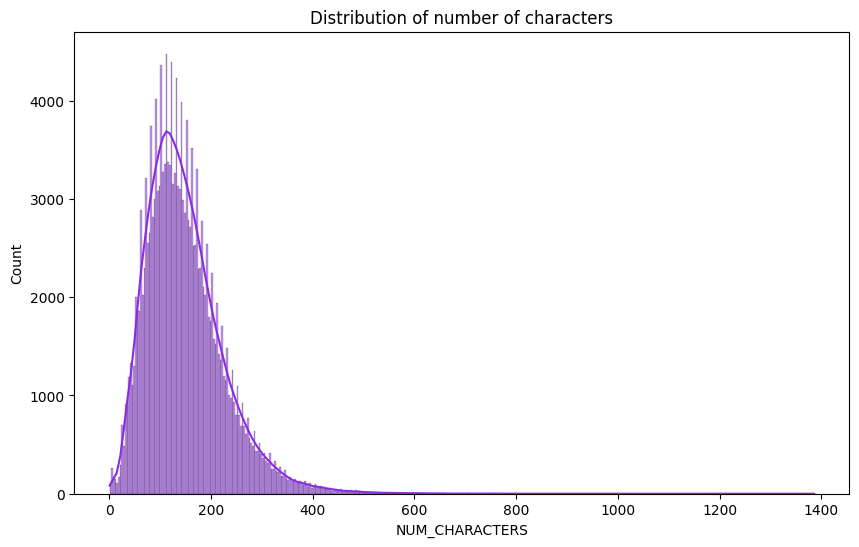

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(10,6))
sns.histplot(data=train, x="NUM_CHARACTERS", color="blueviolet", kde=True)
plt.title("Distribution of number of characters")

print(f"25th percentile: {np.percentile(train['NUM_CHARACTERS'], 25)}")
print(f"50th percentile: {np.percentile(train['NUM_CHARACTERS'], 50)}")
print(f"75th percentile: {np.percentile(train['NUM_CHARACTERS'], 75)}")
print(f"80th percentile: {np.percentile(train['NUM_CHARACTERS'], 80)}")
print(f"90th percentile: {np.percentile(train['NUM_CHARACTERS'], 90)}")
print(f"95th percentile: {np.percentile(train['NUM_CHARACTERS'], 95)}")

In [30]:
train.head()

,PMID,SECTION,TEXT,LINE_NO,TOTAL_LINES,NUM_TOKENS,CHARACTERS_LIST,CHARACTERS_STRING,NUM_CHARACTERS
0,24293578,3,To investigate the efficacy of @ weeks of dail...,1,12,49,"[t, o, , i, n, v, e, s, t, i, g, a, t, e, , ...",t o i n v e s t i g a t e t h e e f f i ...,281
1,24293578,2,A total of @ patients with primary knee OA wer...,2,12,27,"[a, , t, o, t, a, l, , o, f, , @, , p, a, ...",a t o t a l o f @ p a t i e n t s w ...,137
2,24293578,2,Outcome measures included pain reduction and i...,3,12,15,"[o, u, t, c, o, m, e, , m, e, a, s, u, r, e, ...",o u t c o m e m e a s u r e s i n c l u d ...,111
3,24293578,2,Pain was assessed using the visual analog pain...,4,12,14,"[p, a, i, n, , w, a, s, , a, s, s, e, s, s, ...",p a i n w a s a s s e s s e d u s i n g ...,65
4,24293578,2,Secondary outcome measures included the Wester...,5,12,35,"[s, e, c, o, n, d, a, r, y, , o, u, t, c, o, ...",s e c o n d a r y o u t c o m e m e a s u ...,209


### **Implementation:**

In [31]:
# Importing necessary libraries.
import tensorflow as tf
import numpy as np
import random
import string

# Initializing random variables.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing variables.
CHARS = string.ascii_lowercase + string.digits + string.punctuation
CHAR_VOCAB_SIZE = len(CHARS) + 2
CHAR_MAX_LENGTH = int(np.percentile(train["NUM_CHARACTERS"], 95))
CHAR_EMBEDDING_SIZE = 25        # Mentioned in the paper.
NUM_CLASSES = len(classes)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting given dataset into tf.data.Dataset object.
ds_train = tf.data.Dataset.from_tensor_slices((train["CHARACTERS_STRING"].astype(str).values, train["SECTION"].values))
ds_val = tf.data.Dataset.from_tensor_slices((val["CHARACTERS_STRING"].astype(str).values, val["SECTION"].values))
ds_test = tf.data.Dataset.from_tensor_slices((test["CHARACTERS_STRING"].astype(str).values, test["SECTION"].values))

# Optimizing pipeline.
ds_train = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Defining model layers.
char_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens = CHAR_VOCAB_SIZE,
    output_sequence_length = CHAR_MAX_LENGTH,
    output_mode = "int",
    standardize = "lower_and_strip_punctuation",     # This will remove all the punctuations.
    name = "character_vectorizer"
)
train_text = ds_train.map(lambda x,y: x)
char_vectorizer.adapt(train_text.unbatch())
char_vocab_20k = char_vectorizer.get_vocabulary()

character_embedding = tf.keras.layers.Embedding(
    input_dim = len(char_vocab_20k),
    output_dim = CHAR_EMBEDDING_SIZE,
    embeddings_initializer = tf.keras.initializers.RandomUniform(seed=100),
    name = "character_embedding_layer"
)

# Defining model architecture using Keras Functional API.
input = tf.keras.layers.Input(shape=(1,), dtype=tf.string, name="input_layer")
x = char_vectorizer(input)
x = character_embedding(x)
x = tf.keras.layers.Conv1D(64, kernel_size=5, stride=1, name="Conv1D_layer")(x)
x = tf.keras.layers.GlobalAveragePooling1D(name="global_average_pooling_layer")(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output_layer")(x)

# Building the model.
model_3 = tf.keras.Model(input, output, name="model_3")

# Compiling the model.
model_3.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf_keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# Fitting the model.
model_3_history = model_3.fit(
    ds_train,
    epochs = 5,
    validatan_data = ds_val,
    callbacks = [create_tensorboard_callback_hub("model_logs", "model_3"), create_save_weights_callback_hub("model_3")]
)

KeyboardInterrupt: 

## **Model 4: Using a combination of character embeddings and USE**

### **Preparing the Dataset:**

In [32]:
train = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt")
val = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt")
test = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt")

# Adding "LINE_NO" in each PMID.
train["LINE_NO"] = train.groupby("PMID").cumcount()+1
val["LINE_NO"] = val.groupby("PMID").cumcount()+1
test["LINE_NO"] = test.groupby("PMID").cumcount()+1


# Adding "TOTAL_LINES" in each PMID.
train["TOTAL_LINES"] = train.groupby("PMID")["LINE_NO"].transform("max")
val["TOTAL_LINES"] = val.groupby("PMID")["LINE_NO"].transform("max")
test["TOTAL_LINES"] = test.groupby("PMID")["LINE_NO"].transform("max")

# Adding "NUM_TOKENS".
train["NUM_TOKENS"] = train["TEXT"].apply(lambda x: len(x.split()))
val["NUM_TOKENS"] = val["TEXT"].apply(lambda x: len(x.split()))
test["NUM_TOKENS"] = test["TEXT"].apply(lambda x: len(x.split()))

# Adding "CHARACTERS_LIST".
train["CHARACTERS_LIST"] = train["TEXT"].apply(lambda x: list(x.lower()))
val["CHARACTERS_LIST"] = val["TEXT"].apply(lambda x: list(x.lower()))
test["CHARACTERS_LIST"] = test["TEXT"].apply(lambda x: list(x.lower()))

# Adding "CHARACTERS_STRING".
train["CHARACTERS_STRING"] = train["TEXT"].apply(lambda x: " ".join(list(x.lower())))
val["CHARACTERS_STRING"] = val["TEXT"].apply(lambda x: " ".join(list(x.lower())))
test["CHARACTERS_STRING"] = test["TEXT"].apply(lambda x: " ".join(list(x.lower())))

# Adding "NUM_CHARACTERS"
train["NUM_CHARACTERS"] = train["CHARACTERS_LIST"].apply(lambda x: len(x))
val["NUM_CHARACTERS"] = val["CHARACTERS_LIST"].apply(lambda x: len(x))
test["NUM_CHARACTERS"] = test["CHARACTERS_LIST"].apply(lambda x: len(x))

# Encoding target variable.
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
train["SECTION"] = target_encoder.fit_transform(train["SECTION"])
val["SECTION"] = target_encoder.transform(val["SECTION"])
test["SECTION"] = target_encoder.transform(test["SECTION"])

# Getting class mapping.
classes = dict(zip(target_encoder.transform(target_encoder.classes_), target_encoder.classes_))

### **Building Model Architecture:**

#### **Generating Token Embeddings:**

In [33]:
# Importing necessary libraries.
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
import numpy as np
import random

# Initializing random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing varaibles.
VOCAB_SIZE = 68000                                            # Specified in the paper.
MAX_LENGTH = int(np.percentile(train["NUM_TOKENS"], 95))
EMBEDDING_SIZE = 128
NUM_CLASSES = len(classes)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting given dataset into tf.data.Dataset object.
ds_train = tf.data.Dataset.from_tensor_slices((train["TEXT"].astype(str).values, train["SECTION"].values))
ds_val = tf.data.Dataset.from_tensor_slices((val["TEXT"].astype(str).values, val["SECTION"].values))
ds_test = tf.data.Dataset.from_tensor_slices((test["TEXT"].astype(str).values, test["SECTION"].values))

# Optimizing pipeline.
ds_train_tokens = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val_tokens = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test_tokens = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Defining model layers.
use_layer = hub.KerasLayer(
    "https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2",
    input_shape = [],
    dtype = tf.string,
    trainable = False,
    name = "universal_sentence_encoder"
)

# Defining model architecture using Keras Functional API.
token_input = tf_keras.layers.Input(shape=(), dtype=tf.string, name="token_input_layer")
token_x = use_layer(token_input)
token_embedding = tf_keras.layers.Dense(128, activation="relu", name="token_embedding_output")(token_x)  # Condensing the USE embeddings.

# Building the model.
token_embedding_model = tf_keras.Model(token_input, token_embedding, name="token_embedding_model")

#### **Generating Character Embeddings:**

In [34]:
# Importing necessary libraries.
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
import numpy as np
import random
import string

# Initializing random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing variables.
CHARS = string.ascii_lowercase + string.digits + string.punctuation
CHAR_VOCAB_SIZE = len(CHARS) + 2
CHAR_MAX_LENGTH = int(np.percentile(train["NUM_CHARACTERS"], 95))
CHAR_EMBEDDING_SIZE = 128
NUM_CLASSES = len(classes)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting given dataset into tf.data.Dataset object.
ds_train = tf.data.Dataset.from_tensor_slices((train["CHARACTERS_STRING"].astype(str).values, train["SECTION"].values))
ds_val = tf.data.Dataset.from_tensor_slices((val["CHARACTERS_STRING"].astype(str).values, val["SECTION"].values))
ds_test = tf.data.Dataset.from_tensor_slices((test["CHARACTERS_STRING"].astype(str).values, test["SECTION"].values))

# Optimizing pipeline.
ds_train_char = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val_char = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test_char = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Defining model layers.
character_vectorizer = tf_keras.layers.TextVectorization(
    max_tokens = CHAR_VOCAB_SIZE,
    output_sequence_length = CHAR_MAX_LENGTH,
    output_mode = "int",
    standardize = "lower_and_strip_punctuation",     # This will remove all the punctuations.
    name = "character_vectorizer"
)
train_text = ds_train_char.map(lambda x,y: x)
character_vectorizer.adapt(train_text.unbatch())
char_vocab_20k = character_vectorizer.get_vocabulary()

character_embedding = tf_keras.layers.Embedding(
    input_dim = len(char_vocab_20k),
    output_dim = CHAR_EMBEDDING_SIZE,
    embeddings_initializer = tf_keras.initializers.RandomUniform(seed=100),
    name = "character_embedding_layer"
)

# Defining model architecture using Keras Functional API.
char_input = tf_keras.layers.Input(shape=(1,), dtype=tf.string, name="char_input_layer")
char_x = character_vectorizer(char_input)
char_embedding = character_embedding(char_x)
char_embedding_output = tf_keras.layers.Bidirectional(tf_keras.layers.LSTM(24), name="char_Bi_LSTM_layer")(char_embedding)

# Building the model.
char_embedding_model = tf_keras.Model(char_input, char_embedding_output, name="char_embedding_model")

#### **Concatenating embeddings for producing final output:**

In [ ]:
# Concatenating the embeddings.
concat_embedding = tf_keras.layers.Concatenate(name="concat_embedding_layer")([token_embedding_model.output, char_embedding_model.output])

# Applying dropout layer.
concat_embedding_dropout = tf_keras.layers.Dropout(0.5, name="concat_embedding_dropout_layer")(concat_embedding)

# Applying a dense layer (The paper applied a Bi-LSTM layer) on the dropout output.
concat_dense_output = tf_keras.layers.Dense(128, activation="relu", name="concat_dense_output_layer")(concat_embedding_dropout)

# Applying another dropout layer.
concat_dense_dropout = tf_keras.layers.Dropout(0.5, name="concat_dense_dropout_layer")(concat_dense_output)

# Applying a Dense layer to produce the final output.
output = tf_keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output_layer")(concat_dense_dropout)

# Constructing the model.
model_4 = tf_keras.Model(inputs = [token_embedding_model.input, char_embedding_model.input],
                         outputs = output,
                         name = "model_4")

In [ ]:
model_4.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 char_input_layer (InputLay  [(None, 1)]                  0         []                            
 er)                                                                                              
                                                                                                  
 token_input_layer (InputLa  [(None,)]                    0         []                            
 yer)                                                                                             
                                                                                                  
 character_vectorizer (Text  (None, 290)                  0         ['char_input_layer[0][0]']    
 Vectorization)                                                                             

### **Model Architecture Visualization:**

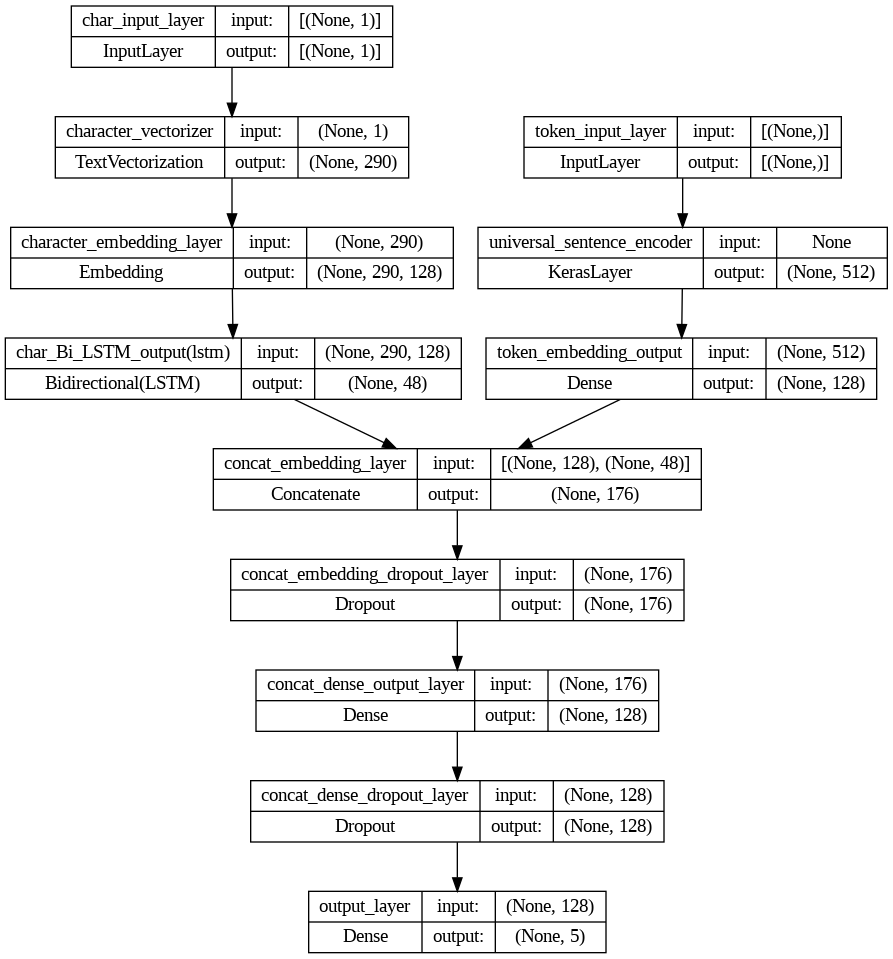

In [ ]:
from tf_keras.utils import plot_model


plot_model(
    model_4,
    show_shapes=True,         # Show tensor shapes
    show_layer_names=True,    # Show layer names
    expand_nested=True,       # <-- This expands internal layers
    to_file="model.png"
)

### **Compiling the Model:**

In [ ]:
model_4.compile(
    loss = tf_keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf_keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

### **Creating efficient data pipeline for our multi-modal model:**

In [ ]:
# Initializing variables.
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting dataset to tf.data.Dataset object.
ds_train = tf.data.Dataset.from_tensor_slices(
    ({"token_input_layer":train["TEXT"], "char_input_layer":train["CHARACTERS_STRING"]}, train["SECTION"])
)
ds_val = tf.data.Dataset.from_tensor_slices(
    ({"token_input_layer":val["TEXT"], "char_input_layer":val["CHARACTERS_STRING"]}, val["SECTION"])
)
ds_test = tf.data.Dataset.from_tensor_slices(
    ({"token_input_layer":test["TEXT"], "char_input_layer":test["CHARACTERS_STRING"]}, test["SECTION"])
)

# Optimizing the data pipeline.
ds_train = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

### **Fitting the Model:**

In [ ]:
model_4_history = model_4.fit(
    ds_train,
    epochs = 5,
    validation_data = ds_val,
    callbacks = [create_tensorboard_callback_hub("model_logs", "model_4"), create_save_weights_callback_hub("model_4")]
)

Saving TensorBoard log files to: model_logs/model_4/22072025-122442
Epoch 1/5
5626/5627 [============================>.] - ETA: 0s - loss: 0.7635 - accuracy: 0.7092
Epoch 1: val_accuracy improved from -inf to 0.76334, saving model to model_weights/model_4.weights.h5
5627/5627 [==============================] - 236s 41ms/step - loss: 0.7635 - accuracy: 0.7092 - val_loss: 0.6234 - val_accuracy: 0.7633
Epoch 2/5
5627/5627 [==============================] - ETA: 0s - loss: 0.6780 - accuracy: 0.7438
Epoch 2: val_accuracy improved from 0.76334 to 0.77337, saving model to model_weights/model_4.weights.h5
5627/5627 [==============================] - 187s 33ms/step - loss: 0.6780 - accuracy: 0.7438 - val_loss: 0.5982 - val_accuracy: 0.7734
Epoch 3/5
5626/5627 [============================>.] - ETA: 0s - loss: 0.6563 - accuracy: 0.7542
Epoch 3: val_accuracy improved from 0.77337 to 0.77840, saving model to model_weights/model_4.weights.h5
5627/5627 [==============================] - 186s 33ms/st

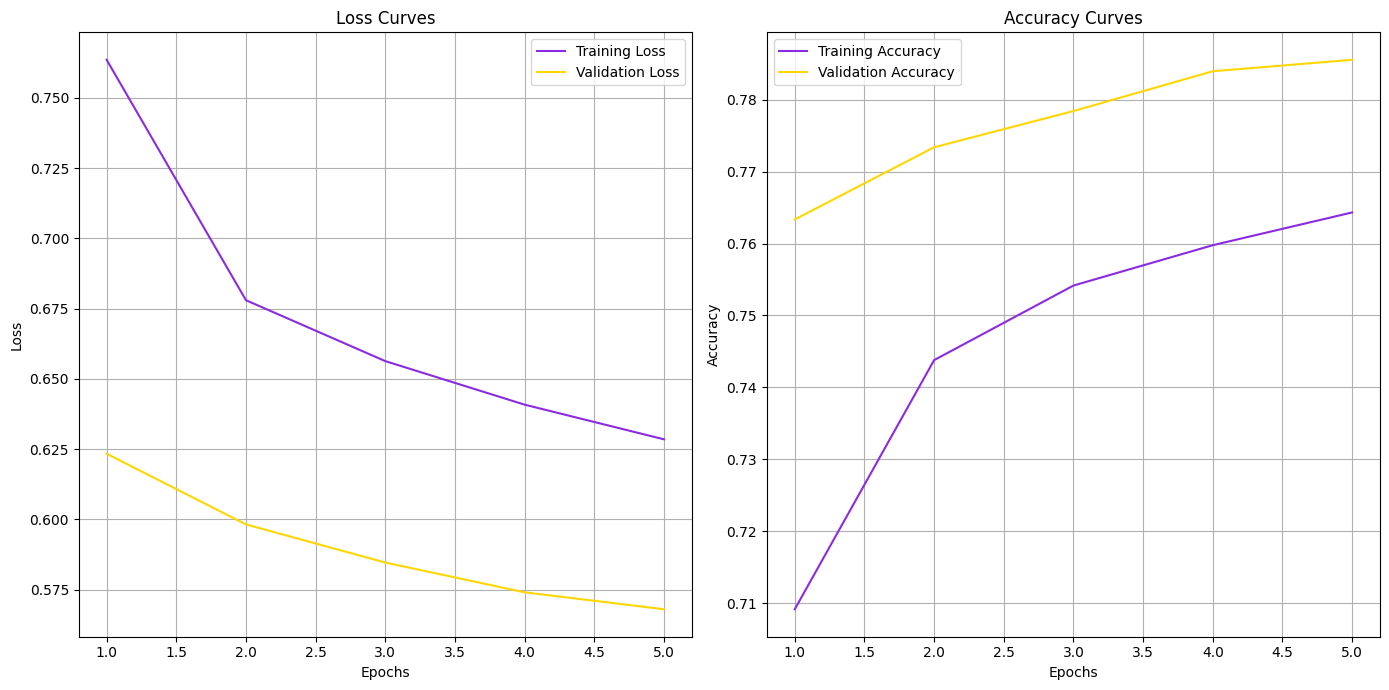

In [ ]:
plot_loss_curves(model_4_history)

### **Metrics Calcuation:**

In [ ]:
Y_pred_soft = model_4.predict(ds_val)
Y_pred = tf.argmax(Y_pred_soft, axis=1)

model_4_results = metrics_calculation(val["SECTION"], Y_pred, average="weighted")

print(f"Model 4 Results:\n{model_4_results}")

945/945 [==============================] - 19s 18ms/step
Model 4 Results:
{'accuracy': 0.7855156891301469, 'precision': 0.7852492765064855, 'recall': 0.7855156891301469, 'f1_score': 0.7813050199631731}


## **Model 5: Token + Character + Positional Embeddings**

### **Preparing the Dataset:**

In [ ]:
train = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt")
val = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt")
test = get_labeled_data("/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt")

# Adding "LINE_NO" in each PMID.
train["LINE_NO"] = train.groupby("PMID").cumcount()+1
val["LINE_NO"] = val.groupby("PMID").cumcount()+1
test["LINE_NO"] = test.groupby("PMID").cumcount()+1


# Adding "TOTAL_LINES" in each PMID.
train["TOTAL_LINES"] = train.groupby("PMID")["LINE_NO"].transform("max")
val["TOTAL_LINES"] = val.groupby("PMID")["LINE_NO"].transform("max")
test["TOTAL_LINES"] = test.groupby("PMID")["LINE_NO"].transform("max")

# Adding "NUM_TOKENS".
train["NUM_TOKENS"] = train["TEXT"].apply(lambda x: len(x.split()))
val["NUM_TOKENS"] = val["TEXT"].apply(lambda x: len(x.split()))
test["NUM_TOKENS"] = test["TEXT"].apply(lambda x: len(x.split()))

# Adding "CHARACTERS_LIST".
train["CHARACTERS_LIST"] = train["TEXT"].apply(lambda x: list(x.lower()))
val["CHARACTERS_LIST"] = val["TEXT"].apply(lambda x: list(x.lower()))
test["CHARACTERS_LIST"] = test["TEXT"].apply(lambda x: list(x.lower()))

# Adding "CHARACTERS_STRING".
train["CHARACTERS_STRING"] = train["TEXT"].apply(lambda x: " ".join(list(x.lower())))
val["CHARACTERS_STRING"] = val["TEXT"].apply(lambda x: " ".join(list(x.lower())))
test["CHARACTERS_STRING"] = test["TEXT"].apply(lambda x: " ".join(list(x.lower())))

# Adding "NUM_CHARACTERS"
train["NUM_CHARACTERS"] = train["CHARACTERS_LIST"].apply(lambda x: len(x))
val["NUM_CHARACTERS"] = val["CHARACTERS_LIST"].apply(lambda x: len(x))
test["NUM_CHARACTERS"] = test["CHARACTERS_LIST"].apply(lambda x: len(x))

# Encoding target variable.
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
train["SECTION"] = target_encoder.fit_transform(train["SECTION"])
val["SECTION"] = target_encoder.transform(val["SECTION"])
test["SECTION"] = target_encoder.transform(test["SECTION"])

# Getting class mapping.
classes = dict(zip(target_encoder.transform(target_encoder.classes_), target_encoder.classes_))
class_list = target_encoder.classes_

25th percentile: 11.0
50th percentile: 12.0
75th percentile: 15.0
80th percentile: 15.0
90th percentile: 17.0
95th percentile: 19.0


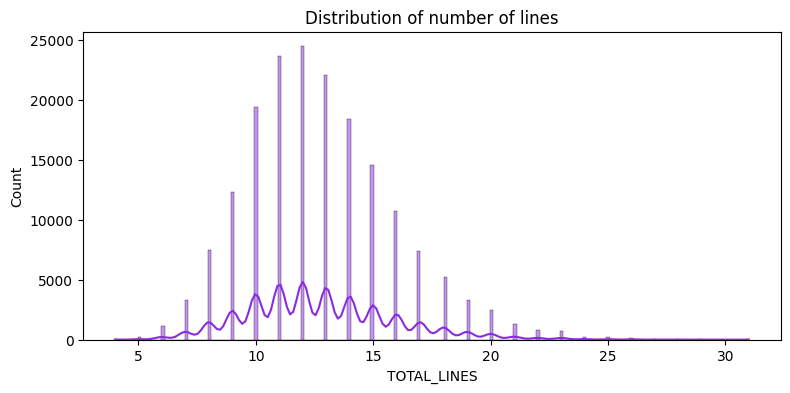

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(9,4))
sns.histplot(data=train, x="TOTAL_LINES", color="blueviolet", kde=True)
plt.title("Distribution of number of lines")

print(f"25th percentile: {np.percentile(train['TOTAL_LINES'], 25)}")
print(f"50th percentile: {np.percentile(train['TOTAL_LINES'], 50)}")
print(f"75th percentile: {np.percentile(train['TOTAL_LINES'], 75)}")
print(f"80th percentile: {np.percentile(train['TOTAL_LINES'], 80)}")
print(f"90th percentile: {np.percentile(train['TOTAL_LINES'], 90)}")
print(f"95th percentile: {np.percentile(train['TOTAL_LINES'], 95)}")

### **One-Hot Encoding Line Number:**
This is done so that the model does not consider one line number value greater compared to another. Our goal is to use it as an **indication of position** and not use it as an ordinal feature.

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder



# One-hot encoding of line number.
line_num_one_hot_encoder = OneHotEncoder(
    handle_unknown = "ignore",
    max_categories = int(np.percentile(train["LINE_NO"], 95))
)

line_num_one_hot = line_num_one_hot_encoder.fit_transform(train[["LINE_NO"]])

line_num_feature_names = line_num_one_hot_encoder.get_feature_names_out()

train[line_num_feature_names] = line_num_one_hot.toarray()
val[line_num_feature_names] = line_num_one_hot_encoder.transform(val[["LINE_NO"]]).toarray()
test[line_num_feature_names] = line_num_one_hot_encoder.transform(test[["LINE_NO"]]).toarray()



# One-hot encoding of total lines.
total_line_one_hot_encoder = OneHotEncoder(
    handle_unknown = "ignore",
    max_categories = int(np.percentile(train["TOTAL_LINES"], 95))
)

total_line_one_hot = total_line_one_hot_encoder.fit_transform(train[["TOTAL_LINES"]])

total_line_feature_names = total_line_one_hot_encoder.get_feature_names_out()

train[total_line_feature_names] = total_line_one_hot.toarray()
val[total_line_feature_names] = total_line_one_hot_encoder.transform(val[["TOTAL_LINES"]]).toarray()
test[total_line_feature_names] = total_line_one_hot_encoder.transform(test[["TOTAL_LINES"]]).toarray()

### **Model Architecture:**

#### **Token Embeddings:**

In [ ]:
# Importing necessary libraries.
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
import numpy as np
import random

# Initializing random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing variables.
TOKEN_EMBEDDING_SIZE = 128

# Defining model layers.
use_layer = hub.KerasLayer(
    "https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2",
    input_shape = [],
    dtype = tf.string,
    trainable = False,
    name = "universal_sentence_encoder"
)

# Defining token embedding generation architecture.
token_input = tf_keras.layers.Input(shape=(), dtype=tf.string, name="token_input_layer")
x = use_layer(token_input)
token_embedding = tf_keras.layers.Dense(TOKEN_EMBEDDING_SIZE, activation="relu", name="token_embedding_output")(x)

# Building the model.
token_embedding_model = tf_keras.Model(token_input, token_embedding, name="token_embedding_model")

#### **Character Embeddings:**

In [ ]:
# Importing necessary libraries.
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
import numpy as np
import random
import string

# Initializing random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing variables.
chars = string.ascii_lowercase + string.digits + string.punctuation
CHAR_VOCAB_SIZE = len(chars) + 2
CHAR_MAX_LENGTH = int(np.percentile(train["NUM_CHARACTERS"], 95))
CHAR_EMBEDDING_SIZE = 24

# Defining model layers.
character_vectorizer = tf_keras.layers.TextVectorization(
    output_mode = "int",
    max_tokens = CHAR_VOCAB_SIZE,
    output_sequence_length = CHAR_MAX_LENGTH,
    standardize = "lower_and_strip_punctuation",
    name = "character_vectorizer"
)
character_vectorizer.adapt(train["CHARACTERS_STRING"].astype(str).values)
char_vocab_20k = character_vectorizer.get_vocabulary()

character_embedding = tf_keras.layers.Embedding(
    input_dim = len(char_vocab_20k),
    output_dim = CHAR_EMBEDDING_SIZE,
    embeddings_initializer = tf_keras.initializers.RandomUniform(seed=100),
    name = "character_embedding_layer"
)

# Defining character embedding generation architecture.
char_input = tf_keras.layers.Input(shape=(1,), dtype=tf.string, name="char_input_layer")
x = character_vectorizer(char_input)
x = character_embedding(x)
char_embedding = tf_keras.layers.Bidirectional(tf_keras.layers.LSTM(CHAR_EMBEDDING_SIZE), name="char_Bi_LSTM_layer")(x)

# Building the model.
char_embedding_model = tf_keras.Model(char_input, char_embedding, name="char_embedding_model")

#### **Positional Embeddings:**

In [ ]:
# Importing necessary libraries.
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
import numpy as np
import random

# Initializing random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing variables.
POSITIONAL_EMBEDDING_SIZE = 32
LINE_NUM_INPUT_SIZE = len(line_num_feature_names)
TOTAL_LINE_INPUT_SIZE = len(total_line_feature_names)

# For "LINE_NO".
line_num_input = tf_keras.layers.Input(shape=(LINE_NUM_INPUT_SIZE,), dtype=tf.float32, name="line_num_input_layer")
line_num_embedding = tf_keras.layers.Dense(POSITIONAL_EMBEDDING_SIZE,
                                           activation="relu", name="line_num_embedding_layer")(line_num_input)
line_num_embedding_model = tf_keras.Model(line_num_input, line_num_embedding, name="line_num_embedding_model")

# For "TOTAL_LINES".
total_line_input = tf_keras.layers.Input(shape=(TOTAL_LINE_INPUT_SIZE,), dtype=tf.float32, name="total_line_input_layer")
total_line_embedding = tf_keras.layers.Dense(POSITIONAL_EMBEDDING_SIZE,
                                           activation="relu", name="total_line_embedding_layer")(total_line_input)
total_line_embedding_model = tf_keras.Model(total_line_input, total_line_embedding, name="total_line_embedding_model")

#### **Final Architecture:**

In [ ]:
# Importing necessary libraries.
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
import numpy as np
import random

# Initializing random seeds.
tf.random.set_seed(100)
np.random.seed(100)
random.seed(100)

# Initializing variables.
NUM_CLASSES = len(classes)

# Concatenating token and character embeddings.
token_char_concat = tf_keras.layers.Concatenate(name="token_char_concat_layer")([token_embedding_model.output,
                                                                                 char_embedding_model.output])
# Applying Dropout layer to token_char_concat.
token_char_concat_dropout = tf_keras.layers.Dropout(0.5, name="token_char_concat_dropout_layer")(token_char_concat)

# Concatenating token_char_concat with the two positional embeddings created.
all_embeddings_concat = tf_keras.layers.Concatenate(name="all_embeddings_concat_layer")([token_char_concat_dropout,
                                                                                         line_num_embedding_model.output,
                                                                                         total_line_embedding_model.output])

# Final output layer.
final_output = tf_keras.layers.Dense(NUM_CLASSES, activation="softmax", name="final_output_layer")(all_embeddings_concat)

# Building the final model.
model_5 = tf_keras.Model(inputs = [token_embedding_model.input,
                                   char_embedding_model.input,
                                   line_num_embedding_model.input,
                                   total_line_embedding_model.input],
                         outputs = final_output,
                         name = "model_5")

In [ ]:
model_5.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 char_input_layer (InputLay  [(None, 1)]                  0         []                            
 er)                                                                                              
                                                                                                  
 token_input_layer (InputLa  [(None,)]                    0         []                            
 yer)                                                                                             
                                                                                                  
 character_vectorizer (Text  (None, 290)                  0         ['char_input_layer[0][0]']    
 Vectorization)                                                                             

#### **Model Architecture Visualization:**

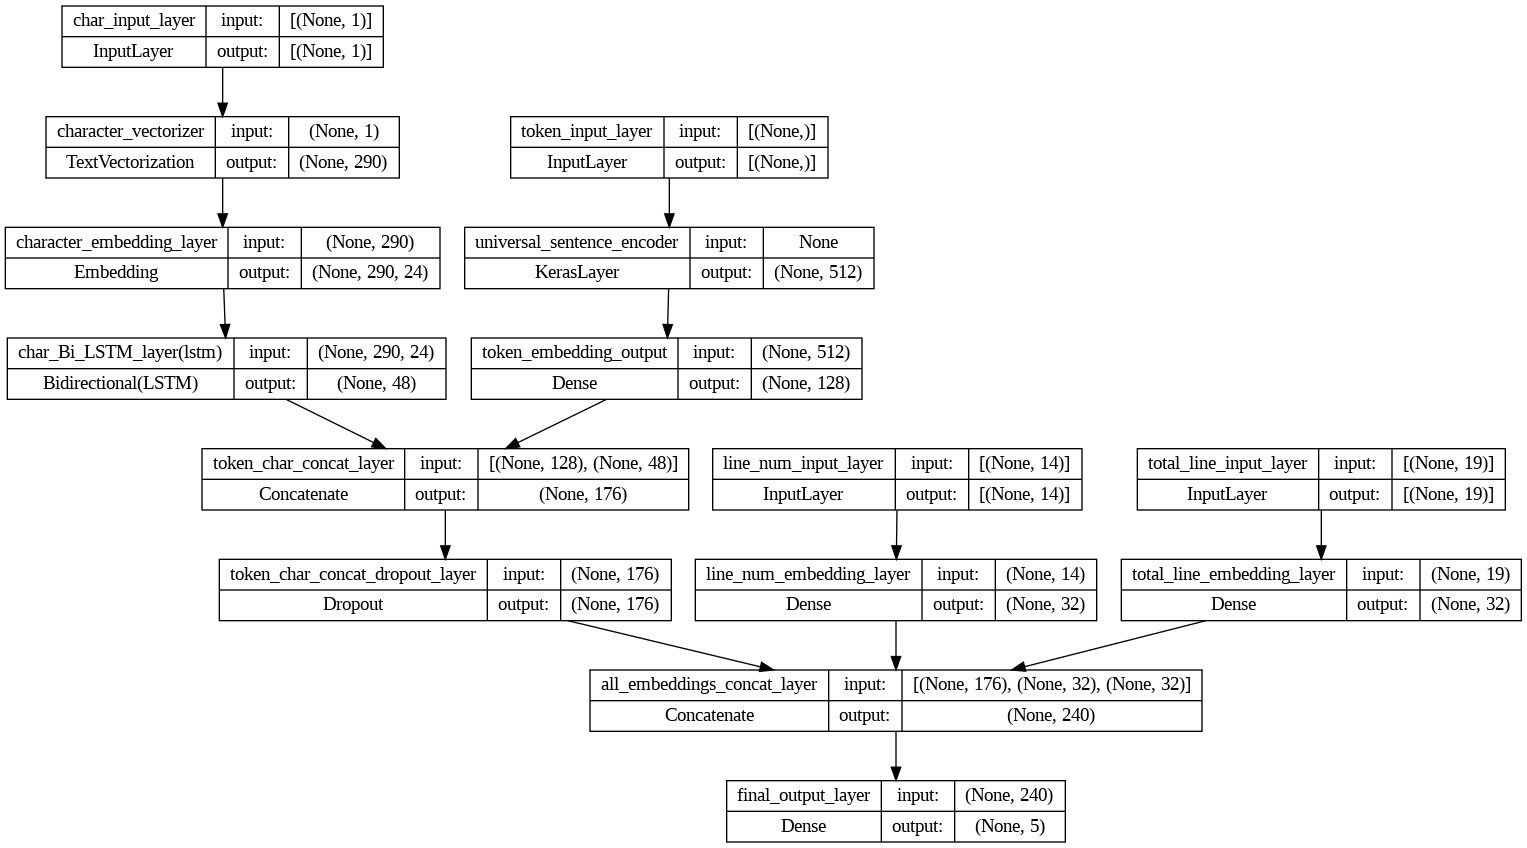

In [ ]:
from tf_keras.utils import plot_model


plot_model(
    model_5,
    show_shapes=True,         # Show tensor shapes
    show_layer_names=True,    # Show layer names
    expand_nested=True,       # <-- This expands internal layers
    to_file="model_5.png"
)

### **Compiling the Model:**

In [ ]:
model_5.compile(
    loss = tf_keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf_keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

### **Building an efficient data pipeline:**

In [ ]:
# Importing necessary libraries.
import tensorflow as tf

# Initializing variables.
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Converting given datasets to tf.data.Dataset objects.
ds_train = tf.data.Dataset.from_tensor_slices(
    ({"token_input_layer":train["TEXT"], "char_input_layer":train["CHARACTERS_STRING"],
      "line_num_input_layer":train[line_num_feature_names], "total_line_input_layer":train[total_line_feature_names]},
     train["SECTION"])
)
ds_val = tf.data.Dataset.from_tensor_slices(
    ({"token_input_layer":val["TEXT"], "char_input_layer":val["CHARACTERS_STRING"],
      "line_num_input_layer":val[line_num_feature_names], "total_line_input_layer":val[total_line_feature_names]},
     val["SECTION"])
)
ds_test = tf.data.Dataset.from_tensor_slices(
    ({"token_input_layer":test["TEXT"], "char_input_layer":test["CHARACTERS_STRING"],
      "line_num_input_layer":test[line_num_feature_names], "total_line_input_layer":test[total_line_feature_names]},
     test["SECTION"])
)

# Optimizing the data pipeline.
ds_train = ds_train.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

### **Fitting the Model:**

In [ ]:
model_5_history = model_5.fit(
    ds_train,
    epochs = 5,
    validation_data = ds_val,
    callbacks = [create_tensorboard_callback_hub("model_logs", "model_5"), create_save_weights_callback_hub("model_5")]
)

Saving TensorBoard log files to: model_logs/model_5/23072025-115735
Epoch 1/5
5627/5627 [==============================] - ETA: 0s - loss: 0.4879 - accuracy: 0.8154
Epoch 1: val_accuracy improved from -inf to 0.85413, saving model to model_weights/model_5.weights.h5
5627/5627 [==============================] - 203s 34ms/step - loss: 0.4879 - accuracy: 0.8154 - val_loss: 0.3865 - val_accuracy: 0.8541
Epoch 2/5
5627/5627 [==============================] - ETA: 0s - loss: 0.3989 - accuracy: 0.8497
Epoch 2: val_accuracy improved from 0.85413 to 0.86111, saving model to model_weights/model_5.weights.h5
5627/5627 [==============================] - 183s 32ms/step - loss: 0.3989 - accuracy: 0.8497 - val_loss: 0.3670 - val_accuracy: 0.8611
Epoch 3/5
5625/5627 [============================>.] - ETA: 0s - loss: 0.3854 - accuracy: 0.8552
Epoch 3: val_accuracy improved from 0.86111 to 0.86406, saving model to model_weights/model_5.weights.h5
5627/5627 [==============================] - 186s 33ms/st

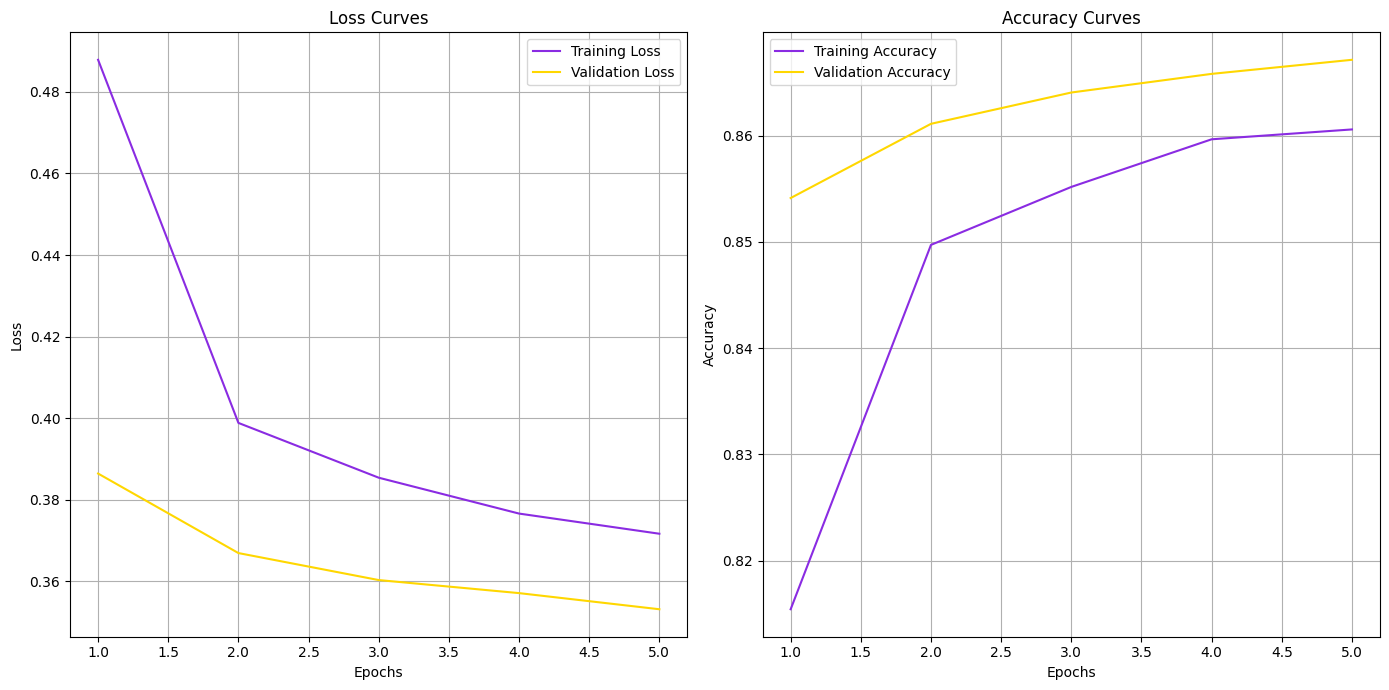

In [ ]:
plot_loss_curves(model_5_history)

### **Metrics Calculation:**

In [ ]:
Y_pred_soft = model_5.predict(ds_val)
Y_pred = tf.argmax(Y_pred_soft, axis=1)

model_5_results = metrics_calculation(val["SECTION"], Y_pred, average="weighted")

print(f"Model 5 Results:\n{model_5_results}")

945/945 [==============================] - 21s 19ms/step
Model 5 Results:
{'accuracy': 0.8671388852111743, 'precision': 0.8684520094224971, 'recall': 0.8671388852111743, 'f1_score': 0.8646040197165322}


### **Analysis of Predictions:**

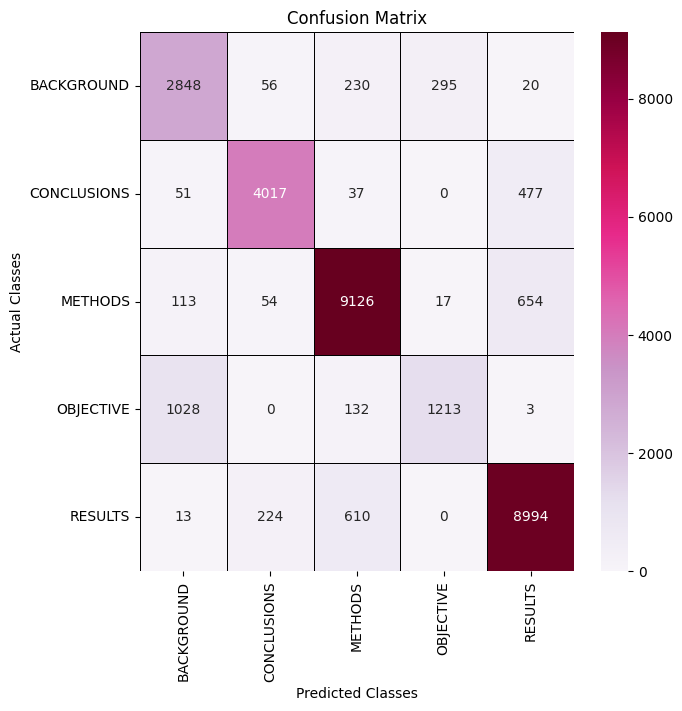

In [ ]:
visualize_confusion_matrix(val["SECTION"], Y_pred, class_list)

In [ ]:
Y_pred

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 0, ..., 4, 1, 1])>